In [ ]:
import sys
!"{sys.executable}" -m pip install datasets

In [4]:
from datasets import load_dataset

# Load the default configuration (color images)
# This automatically downloads the train and test splits.
dataset = load_dataset("mohanty/PlantVillage", "default")

print(dataset)
# DatasetDict({
#     train: Dataset({ features: [...], num_rows: 43596 }),
#     test: Dataset({ features: [...], num_rows: 10709 })
# })


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})


In [5]:
import tensorboard

In [6]:
import sys
import tensorflow as tf

REMOVE DODGY IMAGES

In [7]:
import cv2
from PIL import Image
import os

def what(image_path):
    """Lightweight replacement for the removed `imghdr.what`."""
    try:
        with Image.open(image_path) as img:
            return img.format.lower()
    except Exception:
        return None

In [8]:
data_dir = 'data/raw/apple_color' 

In [9]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [11]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

LOAD DATA

In [12]:
import numpy as np
from matplotlib import pyplot as plt

In [13]:
data = tf.keras.utils.image_dataset_from_directory('data/raw/apple_color')

Found 3171 files belonging to 4 classes.


In [14]:
data_iterator = data.as_numpy_iterator()

In [15]:
batch = data_iterator.next()

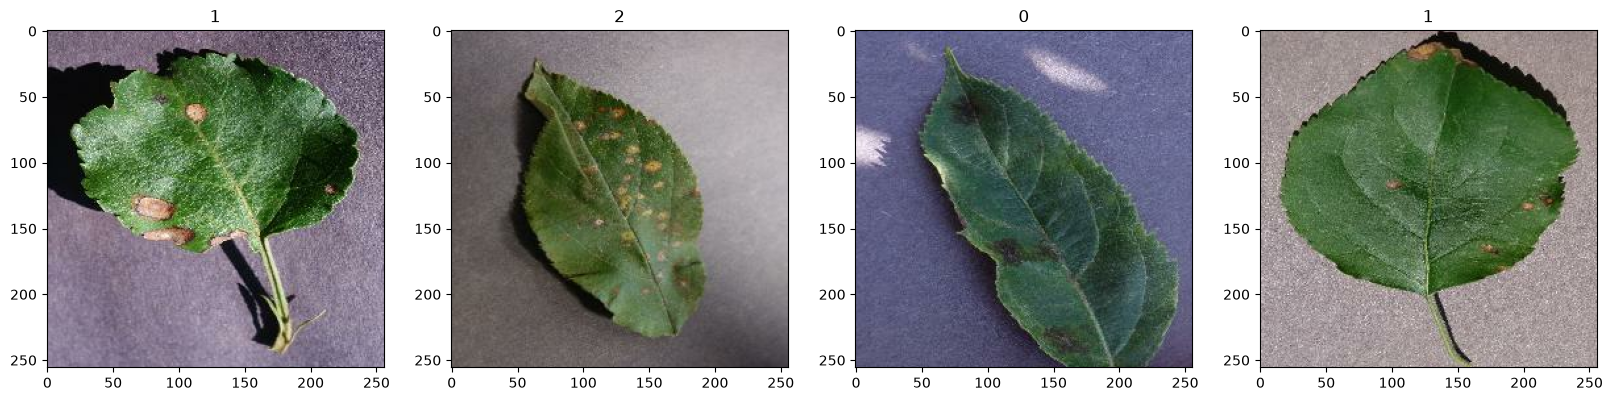

In [16]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

SCALE DATA

In [17]:
data = data.map(lambda x,y: (x/255, y))

In [18]:
data.as_numpy_iterator().next()

(array([[[[0.5372549 , 0.4627451 , 0.5803922 ],
          [0.53333336, 0.45882353, 0.5764706 ],
          [0.53333336, 0.45882353, 0.5764706 ],
          ...,
          [0.5058824 , 0.40784314, 0.52156866],
          [0.5019608 , 0.40392157, 0.5176471 ],
          [0.49803922, 0.4       , 0.5137255 ]],
 
         [[0.53333336, 0.45882353, 0.5764706 ],
          [0.53333336, 0.45882353, 0.5764706 ],
          [0.53333336, 0.45882353, 0.5764706 ],
          ...,
          [0.49803922, 0.4       , 0.5137255 ],
          [0.49411765, 0.39607844, 0.50980395],
          [0.49411765, 0.39607844, 0.50980395]],
 
         [[0.5294118 , 0.45490196, 0.57254905],
          [0.5294118 , 0.45490196, 0.57254905],
          [0.5294118 , 0.45490196, 0.57254905],
          ...,
          [0.4862745 , 0.3882353 , 0.5019608 ],
          [0.49019608, 0.39215687, 0.5058824 ],
          [0.49019608, 0.39215687, 0.5058824 ]],
 
         ...,
 
         [[0.4       , 0.36862746, 0.52156866],
          [0.42352

SPLIT DATA

In [19]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [20]:
train_size


70

In [21]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

START BUILDING THE MODEL

In [22]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [23]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [24]:
model = Sequential()

In [25]:
model.add(Input(shape=(256,256,3)))
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [26]:
loss=tf.losses.SparseCategoricalCrossentropy()

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,697,396 (14.10 MB)

 Trainable params: 3,697,396 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
logdir='logs'

In [30]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [31]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

C:\Users\MANAS KEDIA\Documents\courses\DL 1\ImageClassification\imgclassification\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 52s 687ms/step - accuracy: 0.6647 - loss: 0.8877 - val_accuracy: 0.8594 - val_loss: 0.3868
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 608ms/step - accuracy: 0.8844 - loss: 0.3182 - val_accuracy: 0.9250 - val_loss: 0.2224
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 609ms/step - accuracy: 0.8942 - loss: 0.2777 - val_accuracy: 0.9359 - val_loss: 0.2016
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 618ms/step - accuracy: 0.9321 - loss: 0.1859 - val_accuracy: 0.9328 - val_loss: 0.1952
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 79s 566ms/step - accuracy: 0.9487 - loss: 0.1455 - val_accuracy: 0.9203 - val_loss: 0.2899
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 586ms/step - accuracy: 0.9330 - loss: 0.1745 - val_accuracy: 0.9453 - val_loss: 0.1643
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 574ms/step - accuracy: 0.9656 - loss: 0.0895 - val_accuracy: 0.9531 - val_loss: 0.1482
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 594ms/step - accuracy: 0.9786 - loss: 0.0594 - val_accu

PLOT PERFORMANCE

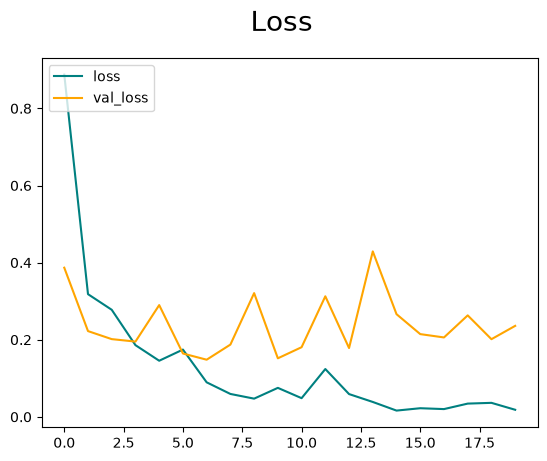

In [32]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

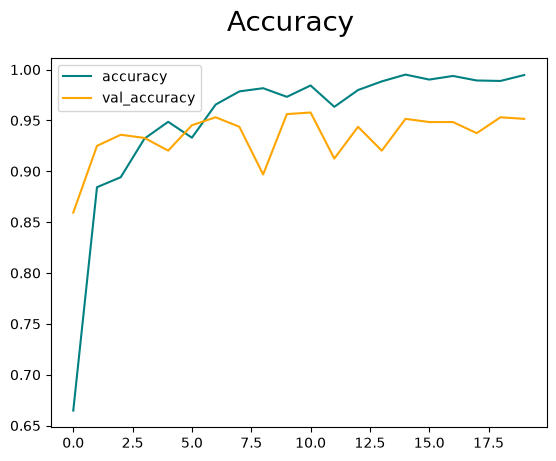

In [33]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

EVALUATE

In [34]:
from tensorflow.keras.metrics import SparseCategoricalAccuracy

acc = SparseCategoricalAccuracy()

In [35]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


In [36]:
print(acc.result())

tf.Tensor(0.9312715, shape=(), dtype=float32)


SAVE MODEL

In [37]:
from tensorflow.keras.models import load_model

In [38]:
os.makedirs('models', exist_ok=True)
model.save(os.path.join('models', 'imageclassifier.keras'))

In [42]:
new_model = load_model(os.path.join('models', 'imageclassifier.keras'))

In [43]:
new_model.predict(np.expand_dims(resize/255, 0))

NameError: name 'resize' is not defined

In [41]:
print(f"Final Accuracy: {hist.history['accuracy'][-1]:.4f} ({hist.history['accuracy'][-1]*100:.2f}%)")

Final Accuracy: 0.9946 (99.46%)
